In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm
import math

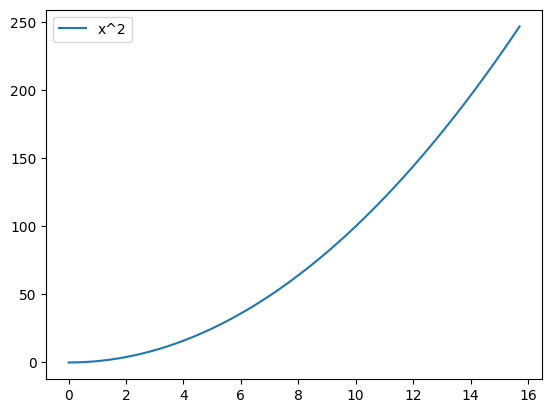

In [14]:
def TargetFunc(x):
    # 目标函数，X方
    return x*x

x = np.arange(0, 5*np.pi, 0.001)
plt.plot(x, [TargetFunc(i) for i in x])
plt.legend(["x^2"])
y = [TargetFunc(i) for i in x]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.125, random_state=1)

In [15]:
# 参数初始化/Xavier初始化
input_dim, hidden_dim, output_dim = 1, 16, 1

W1 = np.random.randn(hidden_dim, input_dim) * np.sqrt(1/input_dim)
W2 = np.random.randn(output_dim, hidden_dim) * np.sqrt(1/hidden_dim)
b1 = np.zeros((hidden_dim, 1))
b2 = np.zeros((output_dim, 1))

In [16]:
cache = {}

def linear(w, x, b): # linear-transform
    return np.matmul(w, x)+b

def relu(x): # relu activate
    return np.where(x>0, x, 0)

def forward(x): # values put in cache for backward later
    cache['inp'] = x
    x = linear(W1, x, b1)
    cache['lin'] = x
    x = relu(x)
    cache['rel'] = x
    output = linear(W2, x, b2) 
    cache['out'] = output
    return output

def loss_fn(y_pred, target): # MSE LOSS
    loss = np.sum((y_pred - target)**2, axis=1, keepdims=True)/len(y_pred)
    cache['loss'] = 2*(y_pred - target)/len(y_pred) # 求个导，这是loss梯度
    return loss

def backward(lr, batch_size):
    global W1, W2, b1, b2

    # output-layer
    delta2 = 1/batch_size * cache['loss'] # 这就是前边儿求的那梯度
    dW2 = 1/batch_size * np.matmul(delta2, cache['rel'].T)
    db2 = 1/batch_size * np.sum(delta2, axis=1, keepdims=True)

    # hidden-layer
    delta1 = np.matmul(W2.T, delta2) * np.where(cache['lin']>0, 1, 0) # relu的导
    dW1 = 1/batch_size * np.matmul(delta1, cache['inp'].T)
    db1 = 1/batch_size * np.sum(delta1, axis=1, keepdims=True)

    # param-update
    W1 -= lr * dW1
    W2 -= lr * dW2
    b1 -= lr * db1
    b2 -= lr * db2


In [18]:
def predict(start, end):
    # 评估，画图对比
    x_plot, y_pred = [], []
    for i in range(start, end+1):
        x = linear(W1, np.array([[i],]), b1)
        x = relu(x)
        output = linear(W2, x, b2)
        x_plot.append(i)
        y_pred.extend(output) # 两种不同添数

    plt.plot(x_plot, [TargetFunc(i) for i in x_plot])
    plt.plot(x_plot,y_pred)
    plt.legend(['Ground Truth', 'Prediction'])

    

In [19]:
def train(x, y, epoches=5, batch_size=10, lr=1e-2, station=100):
    for epoch in tqdm(range(epoches)):
        new_loss = 0
        for batch_idx in range(len(x)//batch_size):
            # 当前批次数据，转成列形状
            x_batch = np.array([
                x[
                    batch_idx*batch_size : min((batch_idx+1)*batch_size, len(x))
                ]
            ])
            y_batch = np.array([
                y[
                    batch_idx*batch_size : min((batch_idx+1)*batch_size, len(x))
                ]
            ])
            # 前传
            y_pred = forward(x_batch)
            # 定损
            loss = np.sum(loss_fn(y_pred, np.array(y_batch)))/len(y_pred)
            new_loss += loss
            # 反传，更参
            backward(lr, batch_size)
        if epoch % station == 0:
            print("Epoch:{}, Loss:{}".format(
                epoch, new_loss/( len(x)//batch_size )
            ))

In [20]:
train(X_train, y_train, epoches=5000, batch_size=32, lr=0.01, station=1000)

  0%|          | 11/5000 [00:00<00:49, 101.29it/s]

Epoch:0, Loss:20213.22168027297


 20%|██        | 1011/5000 [00:10<00:40, 98.16it/s]

Epoch:1000, Loss:39.51475088592834


 40%|████      | 2017/5000 [00:20<00:30, 96.35it/s]

...

 60%|██████    | 3012/5000 [00:31<00:20, 95.59it/s]

Epoch:3000, Loss:33.45369994085861


 80%|████████  | 4013/5000 [00:41<00:10, 96.64it/s]

Epoch:4000, Loss:32.59433053318453


100%|██████████| 5000/5000 [00:54<00:00, 92.39it/s] 


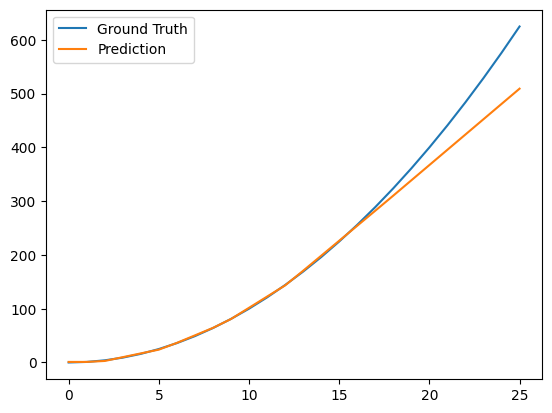

In [23]:
# 查看效果
predict(0, 25)